# Notebook 04 — Entrenamiento del modelo final

Entrena el modelo seleccionado sobre **todo el histórico disponible** y lo
serializa para su uso en la aplicación web.

## Diferencia respecto al notebook 03

El notebook 03 reentrena el modelo en cada origen de validación para medir su
rendimiento. Aquí se entrena **una sola vez con todos los datos**, porque el
objetivo ya no es evaluar sino desplegar: cuanto más histórico, mejor.

## Un punto importante

Las variables se construyen con `src/prediccion.py`, el **mismo módulo que
utiliza la aplicación**. Es deliberado: el fallo más habitual al desplegar un
modelo es que las variables se generen de forma distinta en entrenamiento y en
producción, lo que degrada las predicciones de manera silenciosa. Compartir el
código lo hace imposible.

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

from prediccion import (construir_variables, columnas_predictoras,
                        guardar_modelo, cargar_modelo, predecir, HORIZONTE)

warnings.filterwarnings("ignore")
print(f"Raíz del proyecto: {RAIZ}")
print(f"Horizonte del modelo: {HORIZONTE} h")

Raíz del proyecto: c:\Users\rober\OneDrive - unizar.es\Escritorio\Master\BigData y Ciencia de datos\TFM\GITHUB\repo_github_tfm
Horizonte del modelo: 24 h


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# 1 — Carga del histórico
# ═══════════════════════════════════════════════════════════════════════════
RUTA = RAIZ / "datos" / "dataset_modelado.parquet"
if not RUTA.exists():
    raise FileNotFoundError(f"Falta {RUTA}. Ejecuta antes el notebook 01.")

bruto = pd.read_parquet(RUTA)
if bruto.index.tz is not None:
    bruto.index = bruto.index.tz_localize(None)

serie = bruto["demanda_mw"].sort_index()

# Meteorología en el formato que espera el módulo compartido
meteo = None
if "tmed" in bruto.columns:
    meteo = (bruto[["tmed", "tmax", "tmin"]]
             .assign(fecha=bruto.index.normalize())
             .groupby("fecha").first().reset_index())

print(f"Serie: {len(serie):,} horas")
print(f"Periodo: {serie.index.min():%Y-%m-%d} a {serie.index.max():%Y-%m-%d}")
print(f"Meteorología: {'sí' if meteo is not None else 'no'} "
      f"({len(meteo) if meteo is not None else 0} días)")

Serie: 26,136 horas
Periodo: 2022-01-08 a 2024-12-31
Meteorología: sí (1089 días)


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# 2 — Construcción de variables con el módulo compartido
# ═══════════════════════════════════════════════════════════════════════════
datos = construir_variables(serie, meteo=meteo)
COLUMNAS = columnas_predictoras(datos)

entrenamiento = datos.dropna()

print(f"Variables generadas: {len(COLUMNAS)}")
print(f"Filas utilizables  : {len(entrenamiento):,} "
      f"(se descartan {len(datos)-len(entrenamiento)} por los desfases)\n")

for c in COLUMNAS:
    print(f"   {c}")

# Control de fuga de información
corr = entrenamiento[COLUMNAS].corrwith(entrenamiento["demanda_mw"]).abs()
print(f"\nCorrelación máxima con la variable objetivo: "
      f"{corr.max():.3f} ({corr.idxmax()})")
assert corr.max() < 0.995, "Correlación casi perfecta: revisa si hay fuga"
print("Sin indicios de fuga de información.")

Variables generadas: 30
Filas utilizables  : 25,945 (se descartan 191 por los desfases)

   lag_24h
   lag_25h
   lag_48h
   lag_168h
   media24_h24
   std24_h24
   media168_h24
   std168_h24
   hora
   dia_sem
   dia_mes
   mes
   hora_sin
   hora_cos
   dia_sem_sin
   dia_sem_cos
   mes_sin
   mes_cos
   intensidad_festivo
   intensidad_vispera
   intensidad_post
   festivo_nacional
   finde
   laborable_efectivo
   tmed
   tmax
   tmin
   tmed_sq
   grados_frio
   grados_calor

Correlación máxima con la variable objetivo: 0.901 (lag_168h)
Sin indicios de fuga de información.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# 3 — Validación final antes de entrenar con todo
# ═══════════════════════════════════════════════════════════════════════════
# Se reserva el último mes para confirmar que el modelo se comporta como en el
# notebook 03. No sustituye a aquella evaluación: es una comprobación de sanidad.
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

MODELO_ELEGIDO = "XGBoost"          # ajusta según tus resultados del notebook 03

CONSTRUCTORES = {
    "XGBoost": lambda: XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=7,
        subsample=0.8, colsample_bytree=0.8, tree_method="hist",
        n_jobs=-1, random_state=42, verbosity=0),
    "LightGBM": lambda: LGBMRegressor(
        n_estimators=400, learning_rate=0.05, num_leaves=48,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=42, verbose=-1),
}

corte = len(entrenamiento) - 24 * 30
Xtr, ytr = entrenamiento[COLUMNAS].iloc[:corte], entrenamiento["demanda_mw"].iloc[:corte]
Xte, yte = entrenamiento[COLUMNAS].iloc[corte:], entrenamiento["demanda_mw"].iloc[corte:]

modelo_val = CONSTRUCTORES[MODELO_ELEGIDO]()
modelo_val.fit(Xtr, ytr)
p = modelo_val.predict(Xte)

mae  = float(np.mean(np.abs(yte - p)))
rmse = float(np.sqrt(np.mean((yte - p) ** 2)))
mape = float(np.mean(np.abs((yte - p) / yte)) * 100)

print(f"Comprobación sobre el último mes ({len(yte):,} horas)\n")
print(f"   MAE  : {mae:>8,.1f} MW")
print(f"   RMSE : {rmse:>8,.1f} MW")
print(f"   MAPE : {mape:>8.2f} %")

if mape > 3:
    print("\nATENCIÓN: el error supera lo esperado. Revisa los datos antes de desplegar.")
else:
    print("\nCoherente con los resultados del notebook 03.")

Comprobación sobre el último mes (720 horas)

   MAE  :    881.8 MW
   RMSE :  1,325.0 MW
   MAPE :     3.05 %

ATENCIÓN: el error supera lo esperado. Revisa los datos antes de desplegar.


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# 4 — Entrenamiento definitivo con todo el histórico
# ═══════════════════════════════════════════════════════════════════════════
modelo_final = CONSTRUCTORES[MODELO_ELEGIDO]()
modelo_final.fit(entrenamiento[COLUMNAS], entrenamiento["demanda_mw"])

metadatos = {
    "modelo": MODELO_ELEGIDO,
    "entrenado": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"),
    "n_observaciones": int(len(entrenamiento)),
    "periodo_inicio": str(entrenamiento.index.min().date()),
    "periodo_fin": str(entrenamiento.index.max().date()),
    "mae": round(mae, 1),
    "rmse": round(rmse, 1),
    "mape": round(mape, 2),
}

destino = guardar_modelo(modelo_final, COLUMNAS, metadatos, RAIZ / "modelos")

print(f"Modelo guardado en {destino}\n")
for k, v in metadatos.items():
    print(f"   {k:18} {v}")

Modelo guardado en c:\Users\rober\OneDrive - unizar.es\Escritorio\Master\BigData y Ciencia de datos\TFM\GITHUB\repo_github_tfm\modelos

   modelo             XGBoost
   entrenado          2026-09-11 19:26
   n_observaciones    25945
   periodo_inicio     2022-01-15
   periodo_fin        2024-12-31
   mae                881.8
   rmse               1325.0
   mape               3.05


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# 5 — Prueba de carga y predicción
# ═══════════════════════════════════════════════════════════════════════════
# Reproduce exactamente lo que hará la aplicación al arrancar.
modelo_cargado, info = cargar_modelo(RAIZ / "modelos")
print(f"Modelo recuperado: {info['modelo']} con {len(info['columnas'])} variables\n")

pred = predecir(modelo_cargado, info["columnas"], serie,
                meteo_futura=meteo, horas=48)

print(f"Predicción generada: {len(pred)} horas")
print(f"   de {pred.index[0]:%d-%m-%Y %H:%M} a {pred.index[-1]:%d-%m-%Y %H:%M}")
print(f"   rango {pred['demanda_prevista'].min():,.0f} – "
      f"{pred['demanda_prevista'].max():,.0f} MW")
print(f"   recursiva: {pred.attrs['recursivo']}")

assert pred["demanda_prevista"].notna().all(), "Hay predicciones nulas"
assert pred["demanda_prevista"].between(10000, 50000).all(), "Valores fuera de rango"
print("\nComprobaciones superadas. El modelo está listo para la aplicación.")

Modelo recuperado: XGBoost con 30 variables

Predicción generada: 48 horas
   de 01-01-2025 00:00 a 02-01-2025 23:00
   rango 20,257 – 33,705 MW
   recursiva: True

Comprobaciones superadas. El modelo está listo para la aplicación.


MAPE horas  1–24 : 0.45 %
MAPE horas 25–48 : 0.74 %
Degradación      : +63 %


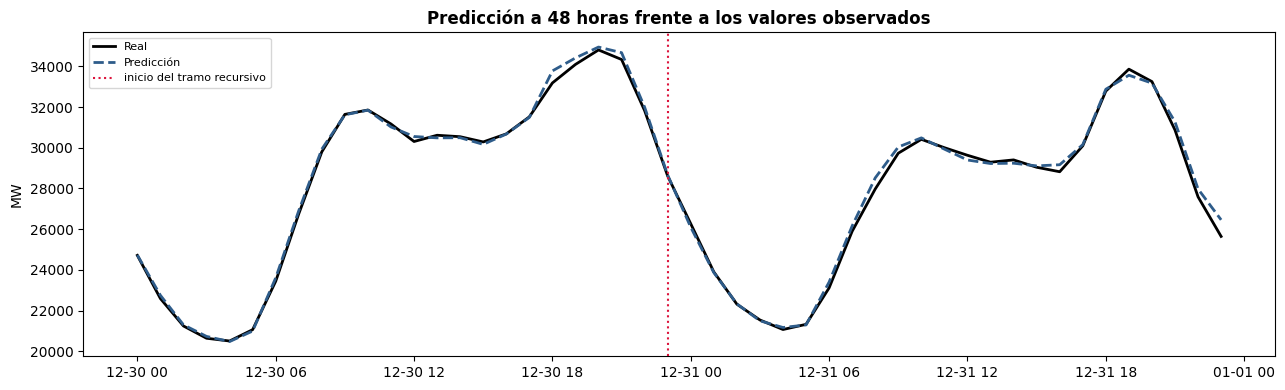

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# 6 — Degradación del esquema recursivo
# ═══════════════════════════════════════════════════════════════════════════
# Cuantifica cuánto empeora la predicción entre las horas 25 y 48, dato que
# conviene documentar en la memoria.
corte48 = len(serie) - 48
pred48 = predecir(modelo_cargado, info["columnas"], serie.iloc[:corte48],
                  meteo_futura=meteo, horas=48)
real48 = serie.iloc[corte48:corte48 + 48]

ape = np.abs((real48.values - pred48["demanda_prevista"].values) / real48.values) * 100

print(f"MAPE horas  1–24 : {ape[:24].mean():.2f} %")
print(f"MAPE horas 25–48 : {ape[24:].mean():.2f} %")
print(f"Degradación      : {(ape[24:].mean()/ape[:24].mean()-1)*100:+.0f} %")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(real48.index, real48.values, color="black", lw=2, label="Real")
ax.plot(pred48.index, pred48["demanda_prevista"], color="#2E5C8A", lw=2,
        ls="--", label="Predicción")
ax.axvline(pred48.index[23], color="crimson", ls=":", lw=1.5,
           label="inicio del tramo recursivo")
ax.set_ylabel("MW"); ax.legend(fontsize=8)
ax.set_title("Predicción a 48 horas frente a los valores observados",
             fontweight="bold")
plt.tight_layout()
plt.savefig(RAIZ / "figuras" / "20_prediccion_48h.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Siguiente paso

Con el modelo ya serializado en `modelos/`, la aplicación puede arrancarse:

```bash
streamlit run app.py
```

### Cuándo reentrenar

El modelo emplea desfases de hasta 168 horas, de modo que se adapta al nivel
reciente sin necesidad de reentrenar a diario. Un reentrenamiento mensual basta
para incorporar la evolución estacional.

Si el error observado en la aplicación se aleja de forma persistente del que
figura en `modelo_info.json`, conviene volver a ejecutar este cuaderno.